In [1]:
from ultralytics import YOLO

# -------------------------------------------------------------------
# 1. LOAD a pretrained YOLOv8 classification model (nano version)
# -------------------------------------------------------------------
model = YOLO("yolov8n-cls.pt")
# This automatically downloads the pretrained weights the first time you run it.

In [2]:
# -------------------------------------------------------------------
# 2. TRAIN the model on our dataset
# -------------------------------------------------------------------
OUTPUT_DIR = r"D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_dataset"

results = model.train(
    data=str(OUTPUT_DIR),     # path to yolo_dataset/ (contains train/, val/, test/)
    epochs=50,
    imgsz=224,
    batch=32,
    patience=10,
    device=0,                 # device=0 means "use GPU index 0" (your RTX 3050). CPU would be device='cpu'
    workers=4,                # number of CPU threads loading images in parallel while GPU trains
    project="breed_classification",   # folder where results/logs/weights get saved
    name="yolov8n_run1",              # subfolder name for this specific run
    verbose=True
)

Ultralytics 8.4.106  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosai

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work\runs\classify\breed_classification\yolov8n_run1")

# -------------------------------------------------------------------
# 1. LOAD the training history (Ultralytics auto-saves this as results.csv)
# -------------------------------------------------------------------
results_csv = pd.read_csv(RUN_DIR / "results.csv")
results_csv.columns = results_csv.columns.str.strip()  # remove stray whitespace from column names
print(results_csv.columns.tolist())  # so we can see exact column names available
results_csv.tail()

['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
45,46,2482.66,0.62162,0.74991,0.95390,0.87635,0.000017,0.000017,0.000017
46,47,2535.18,0.63651,0.74846,0.95499,0.86662,0.000014,0.000014,0.000014
47,48,2589.61,0.61961,0.75027,0.95535,0.86784,0.000011,0.000011,0.000011
48,49,2643.22,0.61374,0.74991,0.95426,0.88408,0.000008,0.000008,0.000008
49,50,2695.43,0.61611,0.74991,0.95463,0.88030,0.000005,0.000005,0.000005


In [4]:
from ultralytics import YOLO

# -------------------------------------------------------------------
# 1. LOAD the best-performing checkpoint saved during training
# -------------------------------------------------------------------
best_model_path = RUN_DIR / "weights" / "best.pt"
model = YOLO(str(best_model_path))

# -------------------------------------------------------------------
# 2. RUN evaluation explicitly on the TEST split (not val!)
# -------------------------------------------------------------------
test_metrics = model.val(
    data=str(OUTPUT_DIR),
    split="test",          # <-- this is the key change: evaluate on held-out test data
    imgsz=224,
    batch=32,
    device=0,
    plots=True,             # this tells Ultralytics to auto-generate & save confusion matrix plots
    project="breed_classification",
    name="yolov8n_run1_test_eval"
)

print("Top-1 Accuracy on TEST set:", test_metrics.top1)
print("Top-5 Accuracy on TEST set:", test_metrics.top5)

Ultralytics 8.4.106  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,514,302 parameters, 0 gradients, 3.4 GFLOPs
train: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_dataset\train... found 9701 images in 62 classes  
val: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_dataset\val... found 2755 images in 62 classes  
test: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_dataset\test... found 1445 images in 62 classes  
WARNING test: Slow image access detected (ping: 0.10.0 ms, read: 1.30.9 MB/s, size: 5.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
test: Scanning D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_dataset\test... 1445 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1445/1445 943.1it/s 1.5s0.1s
test: New cache created: D:\B.Tech\CE-AI\Sem 7\MP\Datasets\Custom_data\yolo_dataset\test.cache
    

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os

# -------------------------------------------------------------------
# 1. GET the ordered list of class names exactly as the model uses them
# -------------------------------------------------------------------
class_names = model.names  # dict {0: 'buffalo_alambadi', 1: 'cattle_amritmahal', ...}
idx_to_name = class_names
name_to_idx = {v: k for k, v in class_names.items()}

test_dir = Path(OUTPUT_DIR) / "test"

y_true = []
y_pred = []

# -------------------------------------------------------------------
# 2. RUN prediction on every image in the test folder, class by class
# -------------------------------------------------------------------
for class_folder in sorted(test_dir.iterdir()):
    if not class_folder.is_dir():
        continue
    true_label_idx = name_to_idx[class_folder.name]

    image_paths = [str(p) for p in class_folder.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
    if not image_paths:
        continue

    # batch predict for speed, rather than one image at a time
    predictions = model.predict(image_paths, imgsz=224, device=0, verbose=False)

    for pred in predictions:
        predicted_label_idx = int(pred.probs.top1)   # top1 predicted class index
        y_true.append(true_label_idx)
        y_pred.append(predicted_label_idx)

print(f"Total test images evaluated: {len(y_true)}")

# -------------------------------------------------------------------
# 3. GENERATE the classification report (precision, recall, F1 per class)
# -------------------------------------------------------------------
target_names = [idx_to_name[i] for i in range(len(idx_to_name))]

report_dict = classification_report(
    y_true, y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.round(3)

# save to CSV so you can put it directly into your report/thesis
report_df.to_csv(RUN_DIR / "per_class_metrics.csv")

print(report_df)

Total test images evaluated: 1445
                     precision  recall  f1-score   support
buffalo_alambadi         0.971   0.917     0.943    36.000
buffalo_banni            0.667   0.476     0.556    21.000
buffalo_bargur           0.615   0.421     0.500    19.000
buffalo_bhadawari        0.560   0.583     0.571    24.000
buffalo_jaffarabadi      0.792   0.864     0.826    22.000
...                        ...     ...       ...       ...
cattle_umblachery        0.917   0.917     0.917    12.000
cattle_vechur            0.769   0.800     0.784    25.000
accuracy                 0.727   0.727     0.727     0.727
macro avg                0.728   0.714     0.714  1445.000
weighted avg             0.734   0.727     0.725  1445.000

[65 rows x 4 columns]


In [8]:
# -------------------------------------------------------------------
# 1. SORT the per-class rows by F1-score to spot weakest breeds
# -------------------------------------------------------------------
# Exclude the summary rows (accuracy, macro avg, weighted avg) from this ranking —
# they aren't per-class scores, so sorting them in would be misleading
per_class_only = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")

worst_10 = per_class_only.sort_values("f1-score").head(10)
best_10  = per_class_only.sort_values("f1-score", ascending=False).head(10)

print("=== 10 WEAKEST-performing breeds ===")
print(worst_10[["precision", "recall", "f1-score", "support"]])

print("\n=== 10 STRONGEST-performing breeds ===")
print(best_10[["precision", "recall", "f1-score", "support"]])

# -------------------------------------------------------------------
# 2. CHECK: does low F1 correlate with low support (few images)?
# -------------------------------------------------------------------
# This helps you argue in your report WHY certain breeds underperform
correlation = per_class_only["f1-score"].corr(per_class_only["support"])
print(f"\nCorrelation between F1-score and number of test images (support): {correlation:.3f}")
# A positive correlation (e.g. > 0.3) supports the argument that classes with
# fewer images perform worse — a natural next step would be collecting more
# data for those specific breeds, or using data augmentation for them.

=== 10 WEAKEST-performing breeds ===
                         precision  recall  f1-score  support
cattle_malvi                 0.182   0.118     0.143     17.0
cattle_gangatiri             0.556   0.385     0.455     13.0
cattle_gaolao                0.667   0.400     0.500     15.0
buffalo_bargur               0.615   0.421     0.500     19.0
cattle_khillar               0.600   0.450     0.514     20.0
buffalo_nagpuri              0.650   0.433     0.520     30.0
cattle_badri                 0.500   0.545     0.522     11.0
cattle_krishna_valley        0.485   0.640     0.552     25.0
buffalo_banni                0.667   0.476     0.556     21.0
cattle_himachali_pahari      0.526   0.588     0.556     17.0

=== 10 STRONGEST-performing breeds ===
                    precision  recall  f1-score  support
cattle_belahi           0.929   1.000     0.963     13.0
cattle_poda_thurpu      1.000   0.895     0.944     19.0
buffalo_alambadi        0.971   0.917     0.943     36.0
cattle_purnea

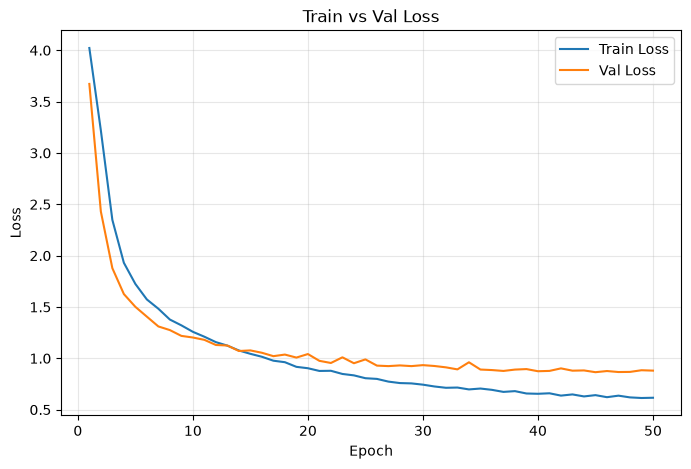

In [11]:
%matplotlib inline
epoch_col = "epoch"
train_loss_col = "train/loss"
val_loss_col = "val/loss"

plt.figure(figsize=(8,5))
plt.plot(results_csv[epoch_col], results_csv[train_loss_col], label="Train Loss")
plt.plot(results_csv[epoch_col], results_csv[val_loss_col], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(RUN_DIR / "loss_curve.png", dpi=150)
plt.show()